In [47]:
import torch
import torch.nn as nn
import torch.nn.init as init
from data_generation import generate_ground_truth, gaussian_plume
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

# MLP-based PINN

- The PINN is a simple MLP with one hidden layer of size 64
- During training the inputs are normalized to the $[-1, 1]$ interval
- The loss consists of following:
  - `loss_data` - MSE between predicted and training value
  - `loss_pde` - PDE residual on collocation points
  - `loss_bc` - Von Neumann boundary condition residual
  - `loss_ic` - Gaussian plume initial condition residual
- Each loss residual (except for data) is weighed by their respective $\lambda_i$ value, where $i$:
  - `ic` - initial condition, default = 1
  - `bc` - boundary condition, default = 1
  - `pde` - PDE, default = 1
- During training `adam_iters` number of iterations with Adam optimizer is executed and then `lbfgs_iters` iterations of LBFGS is executed
- 

In [42]:
class Mlp(nn.Module):
    def __init__(self, hidden:int=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

class Pinn(nn.Module):
    def __init__(self, hidden:int=64):
        super().__init__()
        self.mlp = Mlp(hidden=hidden)

    def forward(self, x):
        return self.mlp(x)


class Normalizer:
    def __init__(self, x_min, x_max, t_min, t_max):
        self.x_min = x_min
        self.x_max = x_max
        self.t_min = t_min
        self.t_max = t_max
        self.sx = 2.0 / (x_max - x_min)
        self.st = 2.0 / (t_max - t_min)
        
    def normalize(self, X):
        Xn = X.clone()
        Xn[:, 0] = 2.0 * (X[:, 0] - self.x_min) / (self.x_max - self.x_min) - 1.0
        Xn[:, 1] = 2.0 * (X[:, 1] - self.t_min) / (self.t_max - self.t_min) - 1.0
        return Xn

    def scale_derivatives(self, qxx, qt):
        qt_n = self.st * qt
        qxx_n = (self.sx**2) * qxx
        return qxx_n, qt_n

def pde_residual(model, X, D, normalizer):
    X = X.clone().detach().requires_grad_(True)
    q = model(X)

    grads = torch.autograd.grad(q, X, torch.ones_like(q), create_graph=True)[0]

    qt = grads[:, 1:2]
    qx = grads[:, 0:1]
    qxx = torch.autograd.grad(qx, X, torch.ones_like(qx), create_graph=True)[0][:, 0:1]

    qxx, qt = normalizer.scale_derivatives(qxx, qt)

    return qt - D*qxx


def pinn_loss(model, X_train, y_train, X_col, X_ic, y_ic, X_bc0, X_bc1, normalizer, losses, D, lambda_ic=1, lambda_bc=1, lambda_pde=1):

    def loss():
        pred_data = model(X_train)
        loss_data = ((pred_data - y_train)**2).mean()
    
        res = pde_residual(model, X_col, D, normalizer)
        loss_pde = (res**2).mean()
    
        pred_ic = model(X_ic)
        loss_ic = ((pred_ic - y_ic)**2).mean()
    
        X_bc0_t = X_bc0.clone().detach().requires_grad_(True)
        X_bc1_t = X_bc1.clone().detach().requires_grad_(True)
        
        q_bc0 = model(X_bc0_t)
        q_bc1 = model(X_bc1_t)
    
        # Neumann BC
        qx_bc0 = torch.autograd.grad(q_bc0, X_bc0_t, torch.ones_like(q_bc0), create_graph=True)[0][:, 0:1]
        qx_bc1 = torch.autograd.grad(q_bc1, X_bc1_t, torch.ones_like(q_bc1), create_graph=True)[0][:, 0:1]
    
        loss_bc = (qx_bc0**2 + qx_bc1**2).mean()
    
        losses["data"].append(loss_data.item())
        losses["pde"].append(loss_pde.item())
        losses["ic"].append(loss_ic.item())
        losses["bc0"].append(loss_bc.item())
        return (
            loss_data + lambda_pde * loss_pde + lambda_ic * loss_ic + lambda_bc * loss_bc
        )

    return loss



def train(model, loss_fn, adam_iters=10000, lbfgs_iters=500, adam_lr=1e-3, lbfgs_lr=1):
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
    losses = []
    for _ in tqdm(range(adam_iters), desc="Training..."):
        loss = loss_fn()
        optimizer_adam.zero_grad()
        loss.backward()
        optimizer_adam.step()
        losses.append(loss.item())

    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=lbfgs_lr,
        max_iter=lbfgs_iters,
        tolerance_grad=1e-9,
        tolerance_change=1e-9,
        history_size=50,
        line_search_fn="strong_wolfe",
    )
    def closure():
        optimizer_lbfgs.zero_grad()
        loss = loss_fn()
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    return losses
    

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

D = 0.01
Nx = 100
Lx = 1
Lt = 10

xs, ts, qs = generate_ground_truth(Lx, Nx, Lt, D)

n_samples = 10
sample_idxs = np.linspace(0, Nx-2, n_samples, dtype=int)
x_samples = xs[sample_idxs]
XX, TT = np.meshgrid(x_samples, ts)

q_samples = qs[:, sample_idxs]

sample_data = np.column_stack([XX.ravel(), TT.ravel(), q_samples.ravel()])

normalizer = Normalizer(0, Lx, 0, Lt)

X_train = torch.tensor(sample_data[:, 0:2], dtype=torch.float32)
X_train = normalizer.normalize(X_train)

y_train = torch.tensor(sample_data[:, 2:3], dtype=torch.float32)

no_collocation = 10000

x_col = np.random.rand(no_collocation) * Lx
t_col = np.random.rand(no_collocation) * Lt

X_col = torch.tensor(np.vstack([x_col, t_col]).T, dtype=torch.float32, requires_grad=True)
X_col = normalizer.normalize(X_col)

x_ic = torch.tensor(xs, dtype=torch.float32).unsqueeze(-1)
t_ic = torch.zeros_like(x_ic)
X_ic = torch.cat([x_ic, t_ic], dim=1)
X_ic = normalizer.normalize(X_ic)
y_ic = torch.tensor(gaussian_plume(xs), dtype=torch.float32).unsqueeze(-1)

t_bc = torch.tensor(ts, dtype=torch.float32).unsqueeze(-1)
x0 = torch.zeros_like(t_bc)
x1 = torch.ones_like(t_bc) * Lx
X_bc0 = torch.cat([x0, t_bc], dim=1)
X_bc0 = normalizer.normalize(X_bc0)
X_bc1 = torch.cat([x1, t_bc], dim=1)
X_bc1 = normalizer.normalize(X_bc1)

X_col = X_col.to(device)
X_ic = X_ic.to(device)
y_ic = y_ic.to(device)
X_bc0 = X_bc0.to(device)
X_bc1 = X_bc1.to(device)


pinn = Pinn().to(device)
pinn_specific_losses = defaultdict(list)
pinn_loss_fn = pinn_loss(pinn, X_train, y_train, X_col, X_ic, y_ic, X_bc0, X_bc1, normalizer, pinn_specific_losses, D)
pinn_losses = train(pinn, pinn_loss_fn)


Training...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:05<00:00, 53.87it/s]


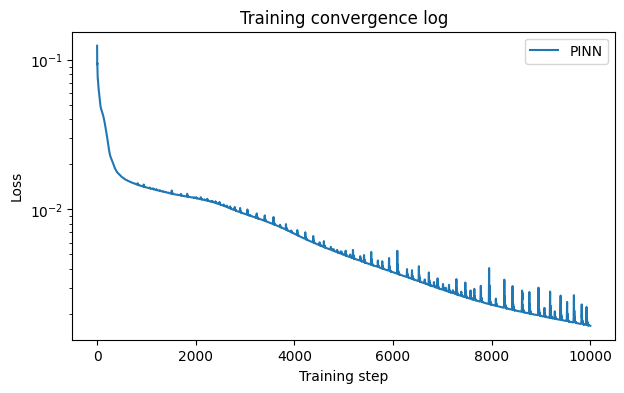

In [48]:

fig = plt.figure(figsize=(7, 4))
plt.plot(pinn_losses, label="PINN")

plt.yscale("log")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.legend()
plt.title("Training convergence log")
plt.show()


PINN RMSE: 0.005225252208917361


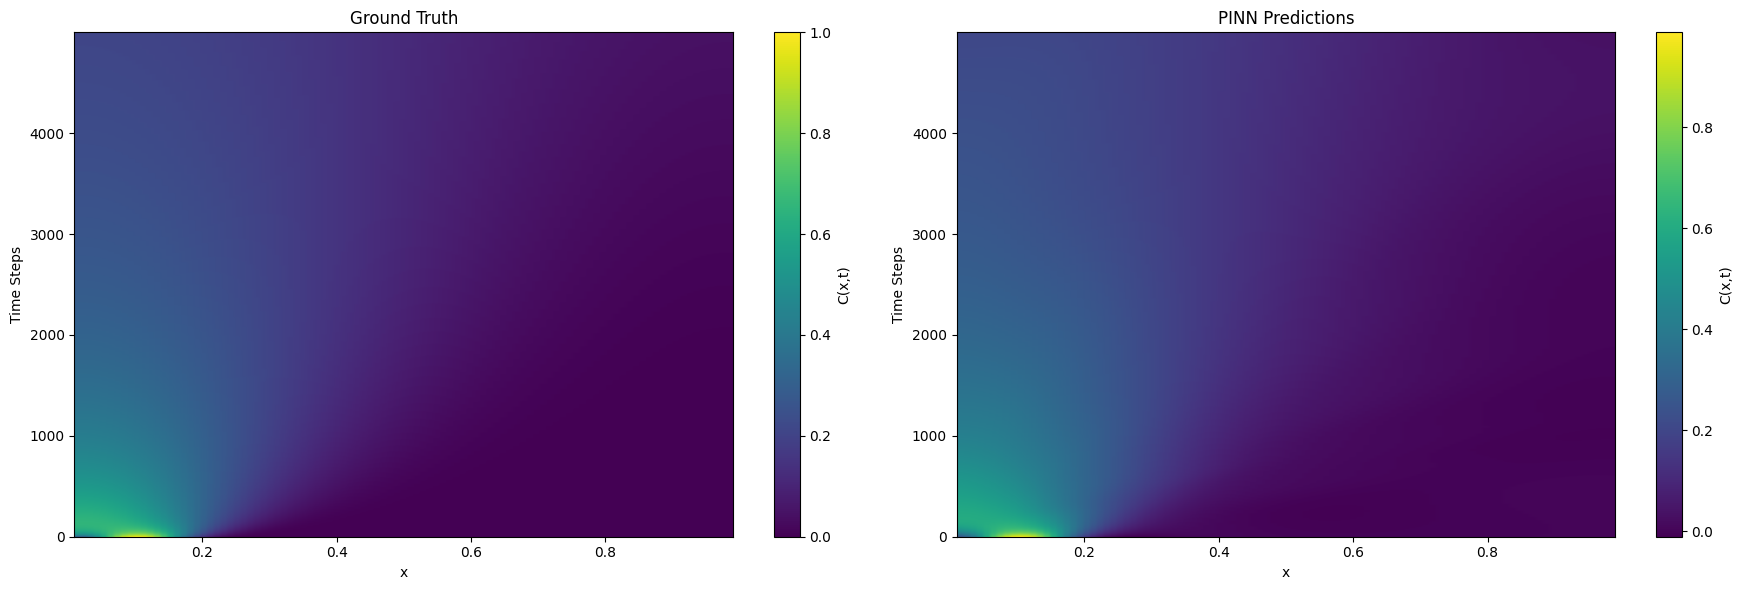

In [52]:
XX, TT = np.meshgrid(xs, ts)
XT = torch.tensor(np.vstack([XX.ravel(), TT.ravel()]).T, dtype=torch.float32)
XT = normalizer.normalize(XT)
Nt = len(ts)

XT = XT.to(device)

with torch.no_grad():
    pred_pinn = pinn(XT).cpu().numpy().reshape(Nt, Nx - 1)
rmse_pinn = np.sqrt(((pred_pinn - qs) ** 2).mean())
print("PINN RMSE:", rmse_pinn)

q_true = qs.copy()
q_pinn = pred_pinn.copy()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))

cax1 = ax1.imshow(
    q_true,
    aspect="auto",
    cmap="viridis",
    origin="lower",
    extent=[xs[0], xs[-1], 0, len(q_true) - 1],
)
ax1.set_title("Ground Truth")
ax1.set_xlabel("x")
ax1.set_ylabel("Time Steps")
fig.colorbar(cax1, ax=ax1, label="C(x,t)")

cax2 = ax2.imshow(
    q_pinn,
    aspect="auto",
    cmap="viridis",
    origin="lower",
    extent=[xs[0], xs[-1], 0, len(q_pinn) - 1],
)
ax2.set_title("PINN Predictions")
ax2.set_xlabel("x")
ax2.set_ylabel("Time Steps")
fig.colorbar(cax2, ax=ax2, label="C(x,t)")

plt.tight_layout()

plt.show()
